<a href="https://colab.research.google.com/github/ponaalagar/tranfer_learning/blob/main/Audio_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub librosa tensorflow tensorflow_hub resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.0 MB/s eta 0:00:00


**Proceudure**

1.import librosa , tf , tf_hub , layers and models from keras , labelEncoder from sklearn.preprocessing and train_test_split from sklearn.model_selection

2.download the dataset of audio  and load the csv for labels

3.Do exploratory data analaysis





In [1]:
#standard
import kagglehub
import os
import pandas as pd
import numpy as np
import librosa
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models

In [3]:
#standard
# Download dataset from Kaggle
path = kagglehub.dataset_download("chrisfilo/urbansound8k")
print("Dataset path:", path)

# Load metadata
metadata_path = os.path.join(path, "UrbanSound8K.csv")
metadata = pd.read_csv(metadata_path)

# Take only 100 samples per class (IMPORTANT)
metadata = metadata.groupby('class').head(100)

Using Colab cache for faster access to the 'urbansound8k' dataset.
Dataset path: /kaggle/input/urbansound8k


In [9]:
#testing
metadata

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
3711,175854-1-0-0.wav,175854,0.060186,0.751776,1,3,1,car_horn
3712,175855-1-0-0.wav,175855,0.165309,0.712897,1,4,1,car_horn
3713,175856-1-0-0.wav,175856,0.287145,0.555461,1,8,1,car_horn
3714,175856-1-1-0.wav,175856,0.932044,1.230957,1,8,1,car_horn


[-0.00010271 -0.00018585 -0.00015815 ... -0.04501794 -0.04447881
 -0.05132776]
16000


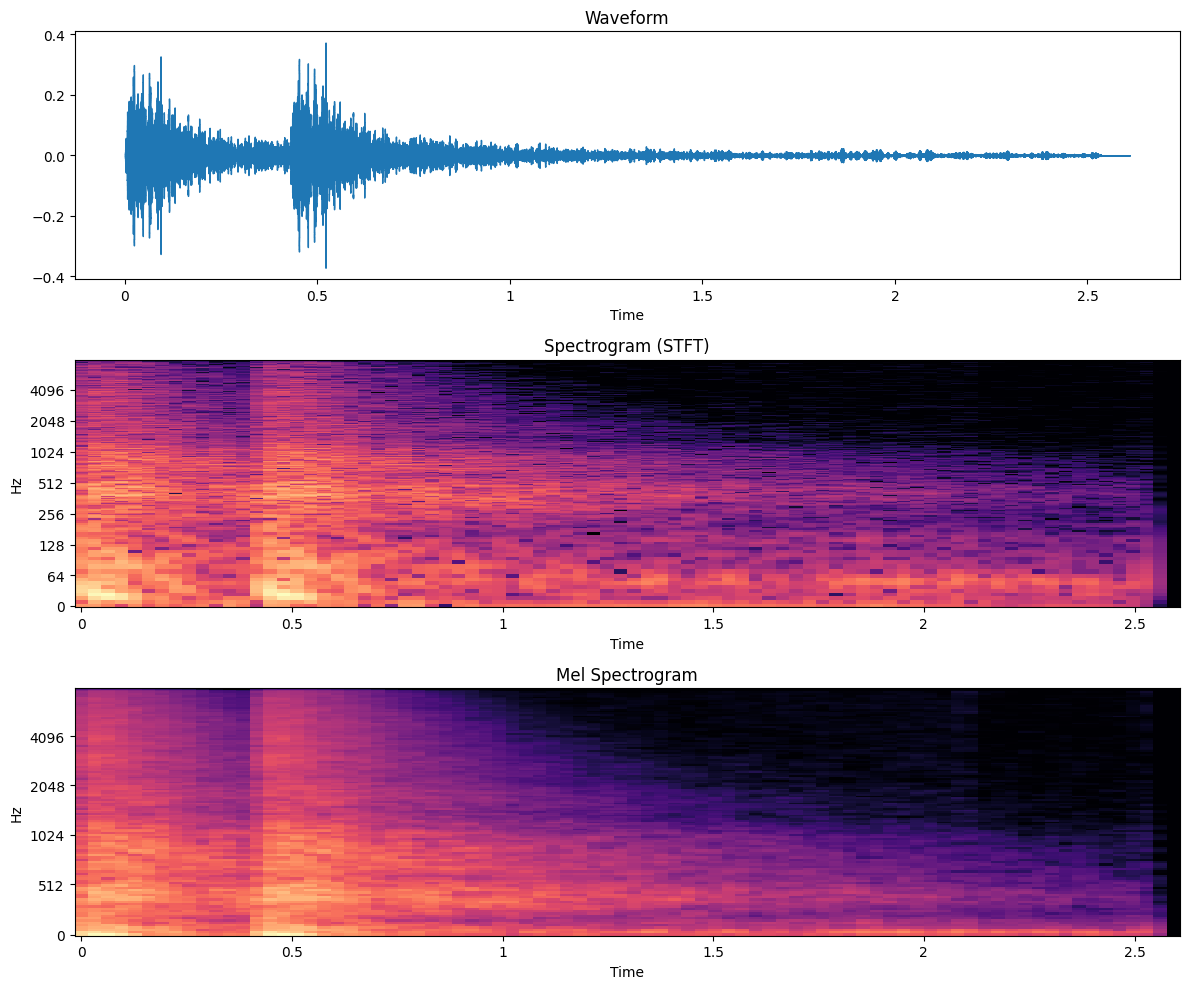

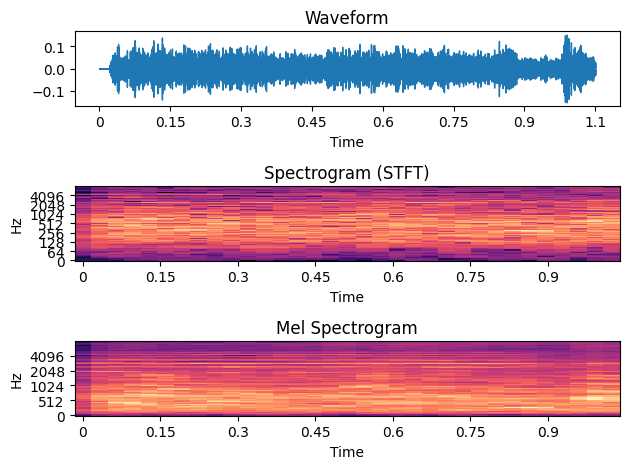

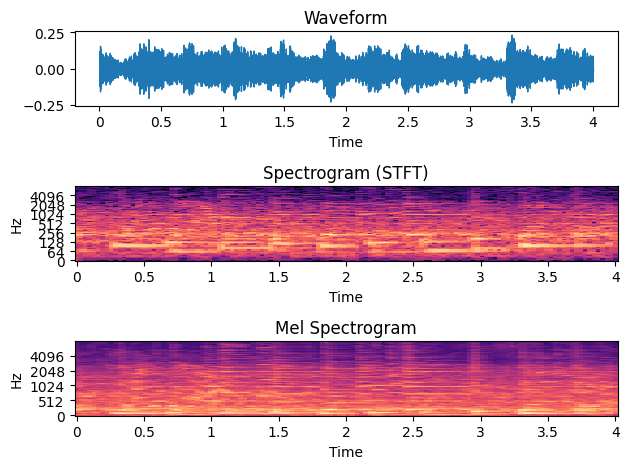

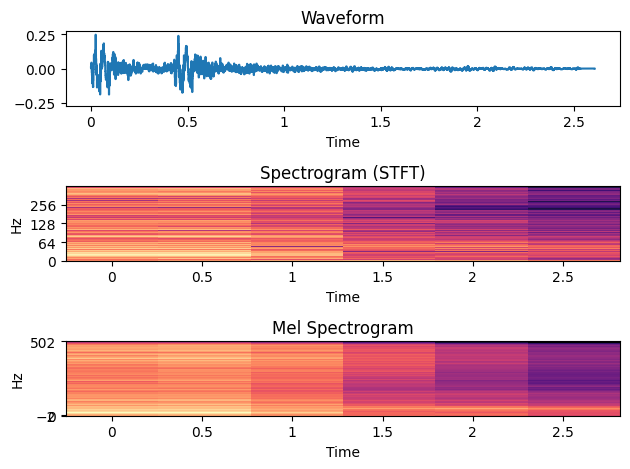

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1050
  warnings.warn(


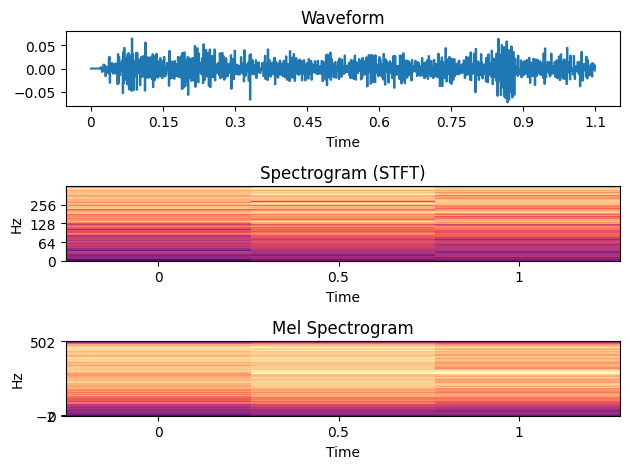

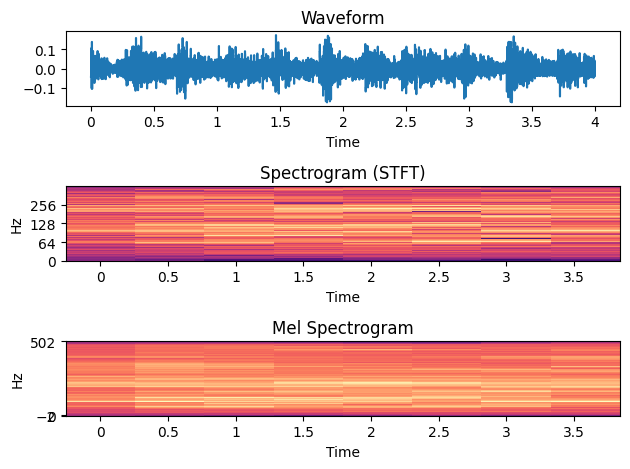

In [41]:
#confirmed for exploratory data analysis
import librosa #--
import librosa.display as ld #--
import librosa.feature as lf #--
import matplotlib.pyplot as plt
import numpy as np

li=["/kaggle/input/urbansound8k/fold1/102305-6-0-0.wav","/kaggle/input/urbansound8k/fold10/100648-1-1-0.wav","/kaggle/input/urbansound8k/fold7/101848-9-0-1.wav"]

sample = librosa.load("/kaggle/input/urbansound8k/fold1/101415-3-0-2.wav",sr=16000)
audio , sr = sample
print(audio)
print(sr)
plt.figure(figsize=(12, 10))
def eda(audio,sr,x):
  # Load the audio file



  # 1. Waveform (Time Domain)
  plt.subplot(3, x, 1)
  ld.waveshow(audio, sr=sr)
  plt.title('Waveform')

  # 2. Spectrogram (STFT)
  plt.subplot(3, x, 2)
  # Compute Short-Time Fourier Transform
  D = librosa.stft(audio)
  # Convert amplitude to decibels for log visualization
  S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
  librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
  plt.title('Spectrogram (STFT)')

  # 3. Mel-Spectrogram
  plt.subplot(3, x, 3)
  # Extract Mel Spectrogram
  mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
  # Convert power to decibels
  mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
  librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
  plt.title('Mel Spectrogram')

  plt.tight_layout()
  plt.show()

for i in li:
  sample , sr = librosa.load(i,sr=16000)
  eda(sample,sr,x=1)
for i in li:
  sample , sr = librosa.load(i,sr=1000)
  eda(sample,sr,x=1)

[-0.00010271 -0.00018585 -0.00015815 ... -0.04501794 -0.04447881
 -0.05132776]
16000
(1025, 47)
[[-1.4135654e-02+0.0000000e+00j -1.7343294e-02+0.0000000e+00j
  -1.6130576e-02+0.0000000e+00j ... -1.5869388e-02+0.0000000e+00j
  -1.4670577e-02+0.0000000e+00j  3.7523311e-02+0.0000000e+00j]
 [ 1.0256846e-02-5.1568993e-03j  8.3956318e-03+2.1464145e-03j
   7.5114276e-03-7.6423667e-04j ...  8.1904018e-03+1.7062030e-04j
   8.3964569e-03+3.7153062e-04j -2.0178554e-03+5.1646404e-02j]
 [-6.3955840e-03+3.7160984e-03j  2.3471692e-03-9.9596940e-04j
   9.5123175e-04-1.5678191e-04j ... -3.7352764e-04-9.9575140e-05j
   1.0918152e-03+3.1086674e-04j -4.8399616e-02-1.9265834e-02j]
 ...
 [ 1.7347627e-05+1.7899720e-07j -8.4349394e-06-5.9342405e-08j
  -3.0307852e-08+1.5611983e-08j ...  4.7704091e-08+3.0921541e-08j
   2.7888894e-04-1.1479563e-04j -1.7400043e-02+7.2008772e-03j]
 [-1.7080234e-05-8.6578467e-08j  2.0348523e-07+8.6054824e-06j
  -1.1524893e-07-1.1502305e-07j ...  1.4848035e-07+2.9312043e-08j
   2.95

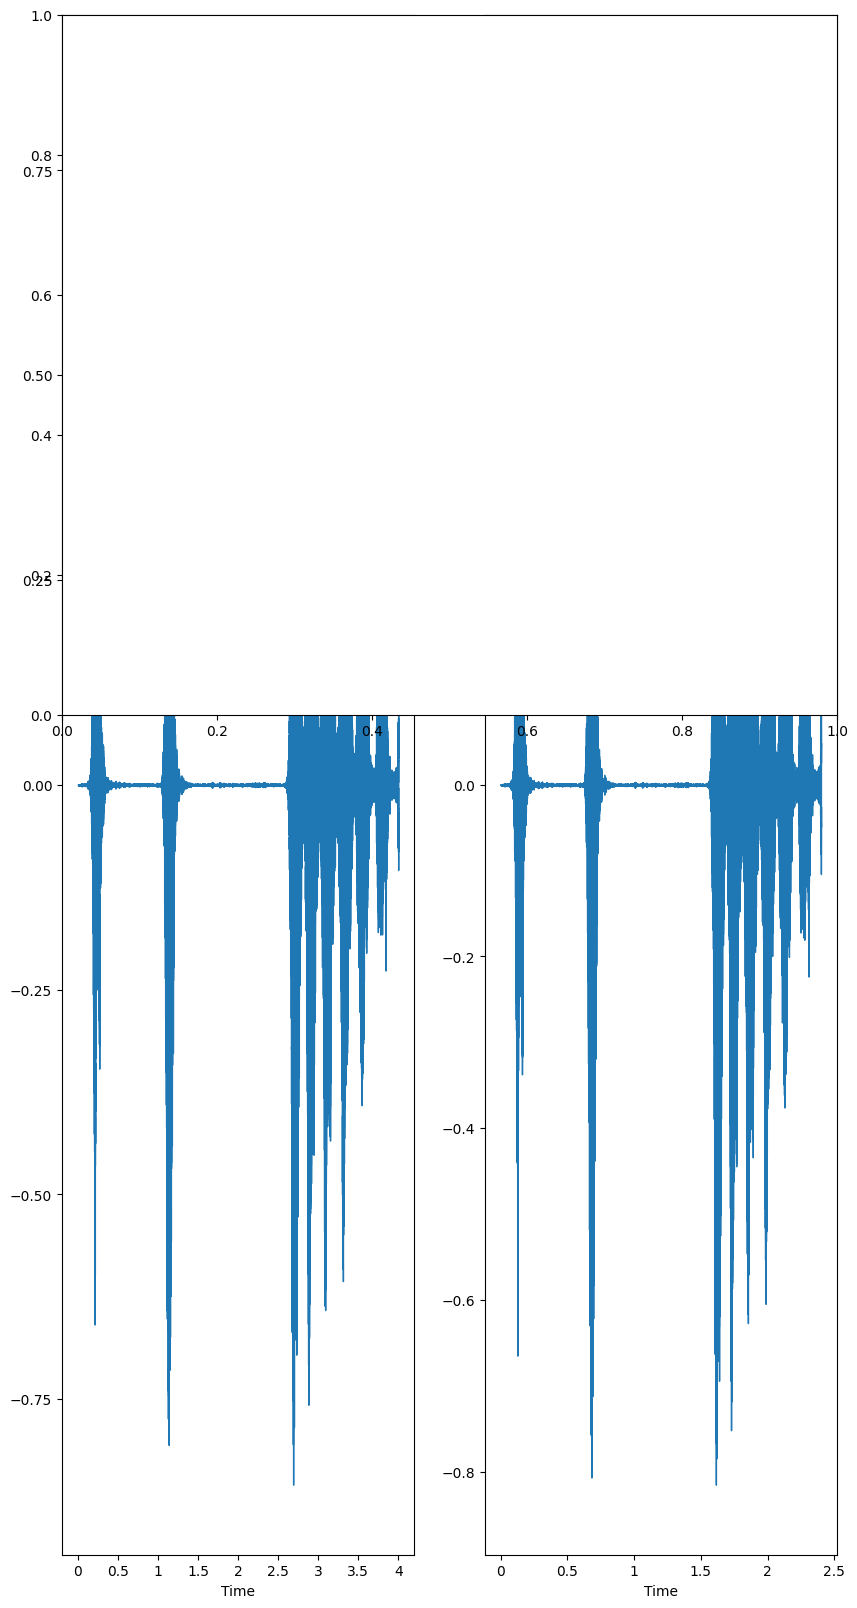

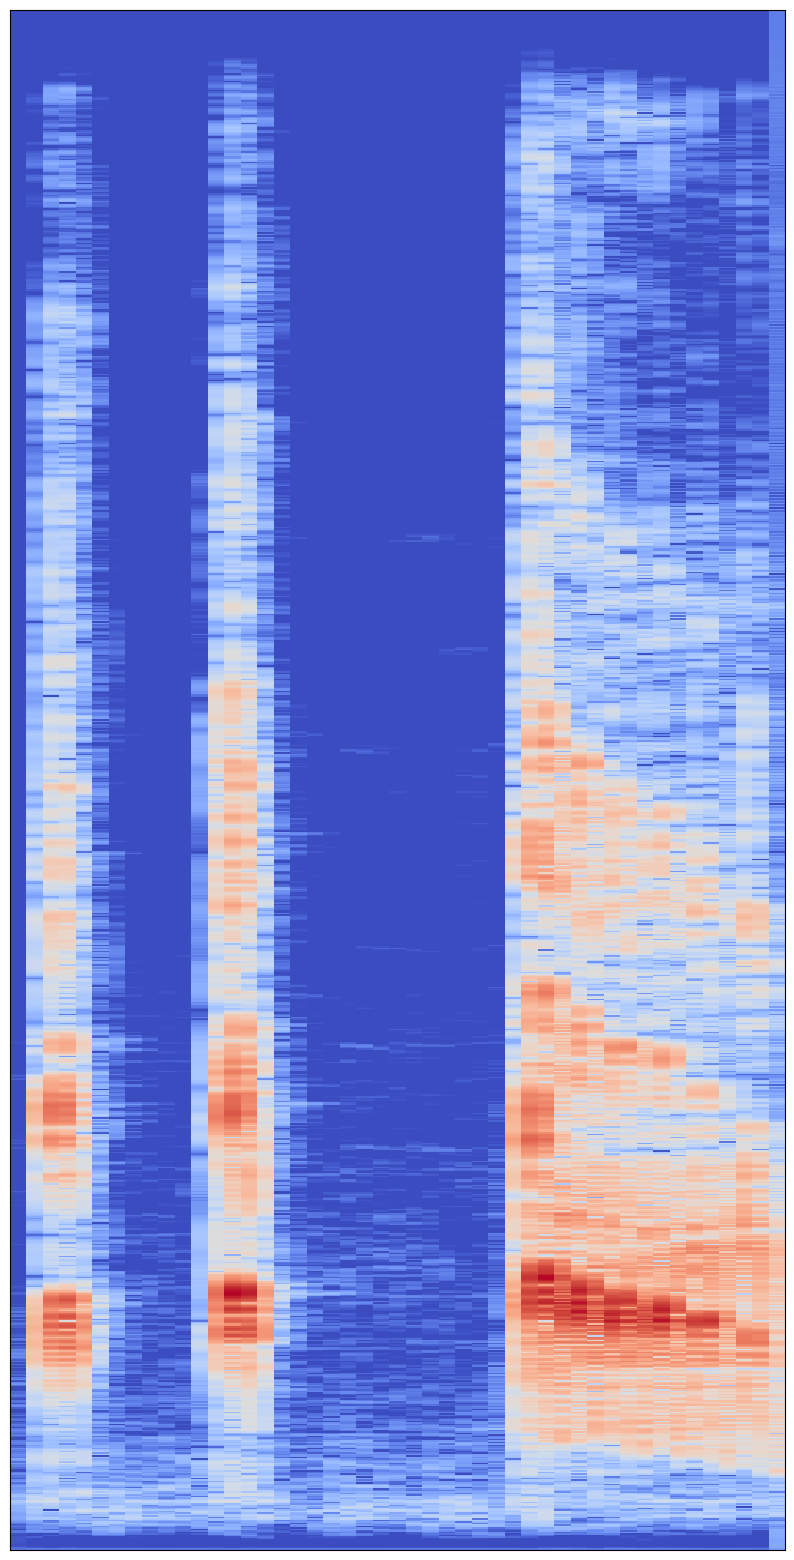

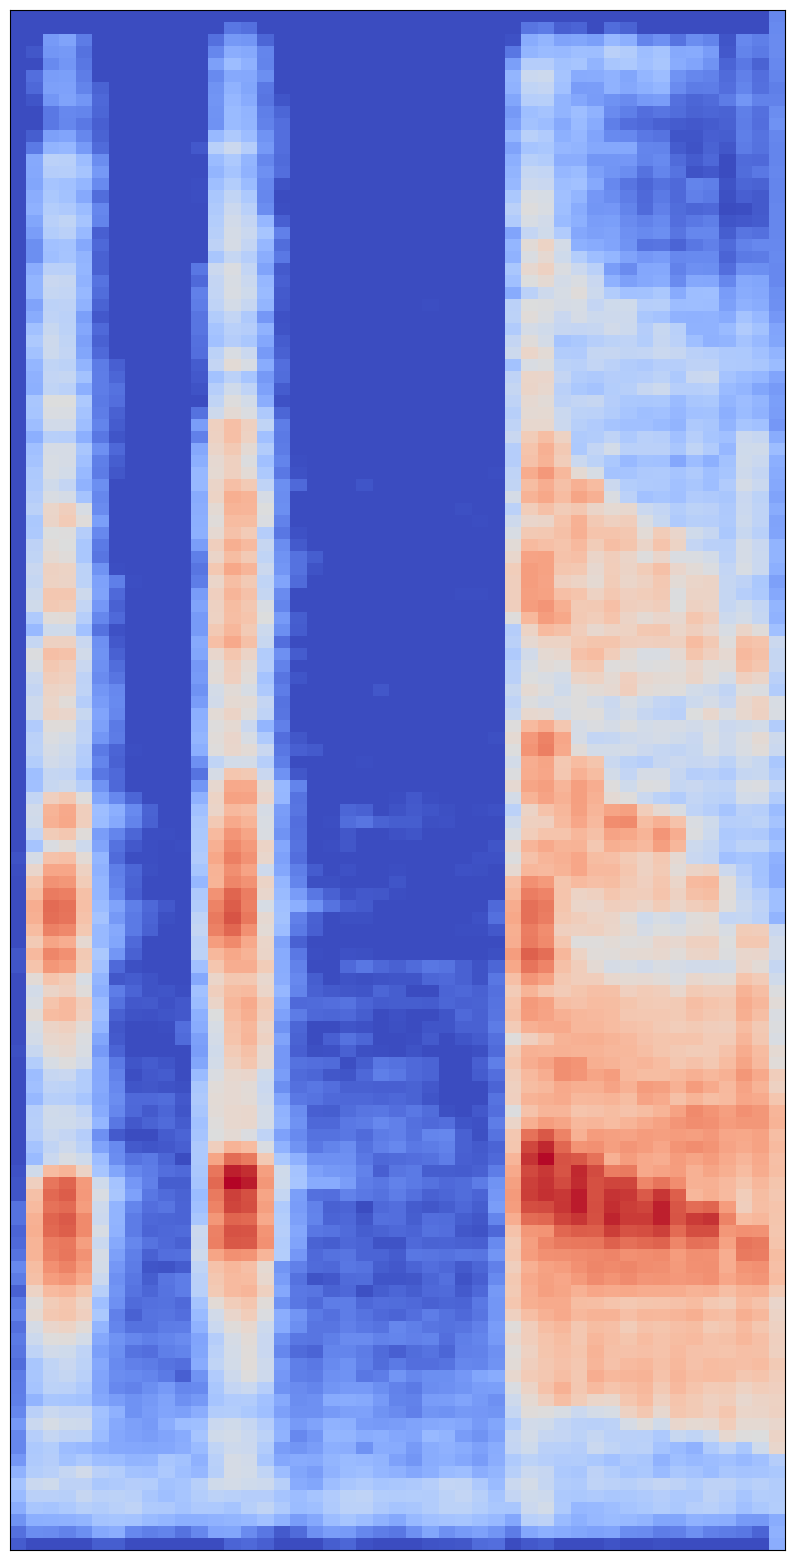

In [45]:
#testing
import librosa.feature as lf
sample = librosa.load("/kaggle/input/urbansound8k/fold1/101415-3-0-2.wav",sr=16000)
audio , sr = sample
print(audio)
print(sr)

plt.figure(figsize=(10,20))
plt.subplot(1,2,1)
ld.waveshow(audio,sr=sr)
sample = librosa.load("/kaggle/input/urbansound8k/fold1/101415-3-0-2.wav",sr=6000)
audio , sr = sample
plt.subplot(1,2,2)
ld.waveshow(audio,sr=10000)

val = librosa.stft(audio)
db = librosa.amplitude_to_db(np.abs(val))
plt.subplot(2,1,1)
plt.figure(figsize=(10,20))
ld.specshow(db)

plt.figure(figsize=(10,20))
mel_spec = lf.melspectrogram(y=audio, sr=sr, n_mels=128)
mel_spec = librosa.power_to_db(mel_spec)
ld.specshow(mel_spec)
print(val.shape)
print(val)


In [4]:
# Load YAMNet model (Transfer Learning)
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

# Feature extraction function
def extract_embedding(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        scores, embeddings, spectrogram = yamnet_model(audio)
        embedding = np.mean(embeddings.numpy(), axis=0)
        return embedding
    except:
        return None

# Prepare dataset
X = []
y = []

for index, row in metadata.iterrows():
    file_name = row['slice_file_name']
    fold = row['fold']
    label = row['class']

    file_path = os.path.join(path, f"fold{fold}", file_name)

    embedding = extract_embedding(file_path)

    if embedding is not None:
        X.append(embedding)
        y.append(label)

# Convert to numpy
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

Feature shape: (1000, 1024)


In [5]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build model
model = models.Sequential([
    layers.Input(shape=(1024,)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(set(y)), activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=8,
    batch_size=8,
    validation_data=(X_test, y_test)
)

Epoch 1/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5800 - loss: 1.4415 - val_accuracy: 0.8650 - val_loss: 0.7836
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8213 - loss: 0.6969 - val_accuracy: 0.9200 - val_loss: 0.4379
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8850 - loss: 0.4567 - val_accuracy: 0.9450 - val_loss: 0.2949
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9062 - loss: 0.3510 - val_accuracy: 0.9500 - val_loss: 0.2455
Epoch 5/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9262 - loss: 0.2881 - val_accuracy: 0.9500 - val_loss: 0.2193
Epoch 6/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9475 - loss: 0.2334 - val_accuracy: 0.9550 - val_loss: 0.1912
Epoch 7/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9362 - loss: 0.2300 - val_accuracy: 0.9500 - val_loss: 0.1841
Epoch 8/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9575 - loss: 0.1784 - val_accuracy: 0.9450 - v

In [6]:
loss, acc = model.evaluate(X_train, y_train)

print("Accuracy:", acc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9825 - loss: 0.0959
Accuracy: 0.9825000166893005


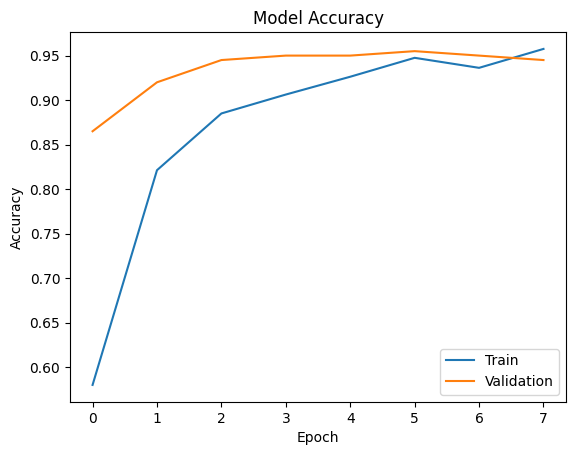

In [7]:
# Plot accuracy
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

In [8]:
def predict_audio(file_path, actual_class):
    audio, sr = librosa.load(file_path, sr=16000)

    scores, embeddings, _ = yamnet_model(audio)
    embedding = np.mean(embeddings.numpy(), axis=0)
    embedding = embedding.reshape(1, -1)

    prediction = model.predict(embedding)
    predicted_label = np.argmax(prediction)
    class_name = le.inverse_transform([predicted_label])

    print("Actual Class   :", actual_class)
    print("Predicted Class:", class_name[0])

# Example prediction (change path if needed)
sample_row = metadata.sample(1).iloc[0]
sample_path = os.path.join(
    path,
    f"fold{sample_row['fold']}",
    sample_row['slice_file_name']
)

predict_audio(sample_path, sample_row['class'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Actual Class   : children_playing
Predicted Class: children_playing
